# 01 — Descriptive Analysis

**GraphRAG-NK · Milestone 10**

First end-to-end view of the knowledge graph after a pilot ingest.
Run `python scripts/mine_one.py --repo python/cpython` and
`python scripts/run_pipeline.py` before opening this notebook.

Sections:
1. Node counts per label
2. Signal counts per layer × category (heatmap)
3. Top lexical markers
4. Classifier label distribution vs. signal layer-diversity
5. First cut at RQ5: silent units (classifier says NK, no linguistic signals)

> **Note on `Signal.payload_json`.** Supplementary per-signal provenance is
> stored as a JSON *string* (`sig.payload_json`), because Neo4j cannot store
> nested maps as properties. To query into it, use
> `apoc.convert.fromJsonMap(sig.payload_json).<key>` in Cypher, or
> `json.loads(row['payload_json'])` in pandas. The queries below do not need
> it — the key provenance lives on the LexicalMarker, RhetoricalFigure, and
> ClassifierVerdict nodes as primitive properties.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('.').resolve().parent))

from neo4j import GraphDatabase
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from settings import settings

driver = GraphDatabase.driver(
    settings.neo4j_uri,
    auth=(settings.neo4j_user, settings.neo4j_password)
)

def q(cypher, **params):
    """Run a Cypher query and return a DataFrame."""
    with driver.session() as s:
        result = s.run(cypher, **params)
        return pd.DataFrame([r.data() for r in result])

print('Connected to Neo4j.')

Connected to Neo4j.


## 1. Node counts per label

Sanity check: are all layers populated?

In [2]:
df_nodes = q("""
    CALL apoc.meta.stats()
    YIELD labels
    UNWIND keys(labels) AS label
    RETURN label, labels[label] AS count
    ORDER BY count DESC
""")
df_nodes.style.background_gradient(subset=['count'], cmap='Blues')

,label,count
0,Signal,1630
1,TextUnit,781
2,ClassifierVerdict,781
3,Commit,369
4,Repository,100
5,Actor,94
6,PullRequest,59
7,Issue,30
8,LexicalMarker,5
9,RhetoricalFigure,1


## 2. Signal counts per layer × category (heatmap)

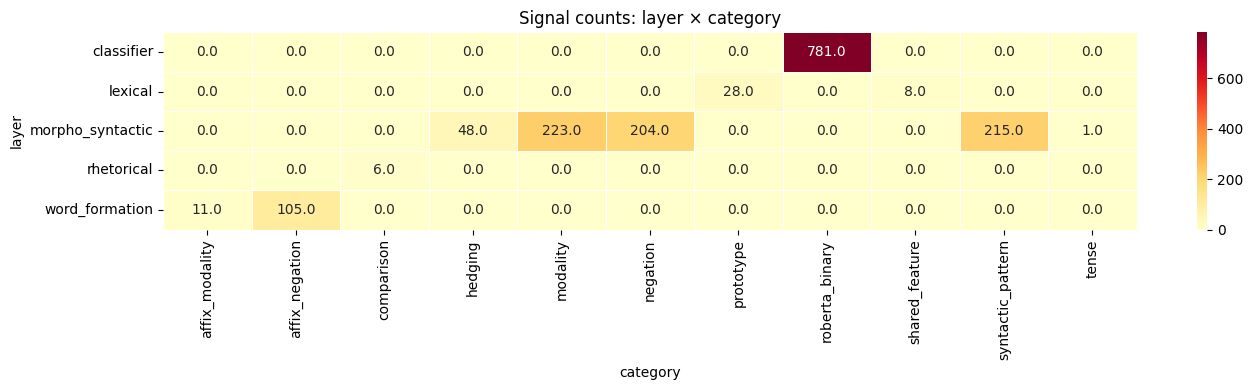

Total signals: 1,630


In [6]:
df_signals = q("""
    MATCH (s:Signal)
    RETURN s.layer AS layer, s.category AS category, count(*) AS n
    ORDER BY layer, n DESC
""")

if df_signals.empty:
    print('No signals yet — run the pipeline first.')
else:
    pivot = df_signals.pivot_table(index='layer', columns='category', values='n', fill_value=0)
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(pivot, annot=True, fmt="2", cmap='YlOrRd', ax=ax, linewidths=.5)
    ax.set_title('Signal counts: layer × category')
    plt.tight_layout()
    plt.show()
    print(f'Total signals: {df_signals.n.sum():,}')

In [20]:
df_roberta = q("""
    MATCH (s:Signal {layer:'classifier'})
    RETURN s
""")
print(df_roberta.head(1))

                                                   s
0  {'rule_id': 'clf.roberta_binary', 'rule_versio...


## 3. Top lexical markers (RQ1)

Which NK lexemes recur most in the corpus?

In [7]:
df_markers = q("""
    MATCH (s:Signal {layer:'lexical'})-[:MATCHES_MARKER]->(m:LexicalMarker)
    RETURN m.lemma AS lemma, m.category AS category,
           m.polarity AS polarity, count(s) AS occurrences
    ORDER BY occurrences DESC LIMIT 30
""")
df_markers

,lemma,category,polarity,occurrences
0,error,prototype,pejorative,25
1,missing,shared_feature,neutral,7
2,unclear,prototype,neutral,2
3,bug,prototype,pejorative,1
4,lack of,shared_feature,pejorative,1


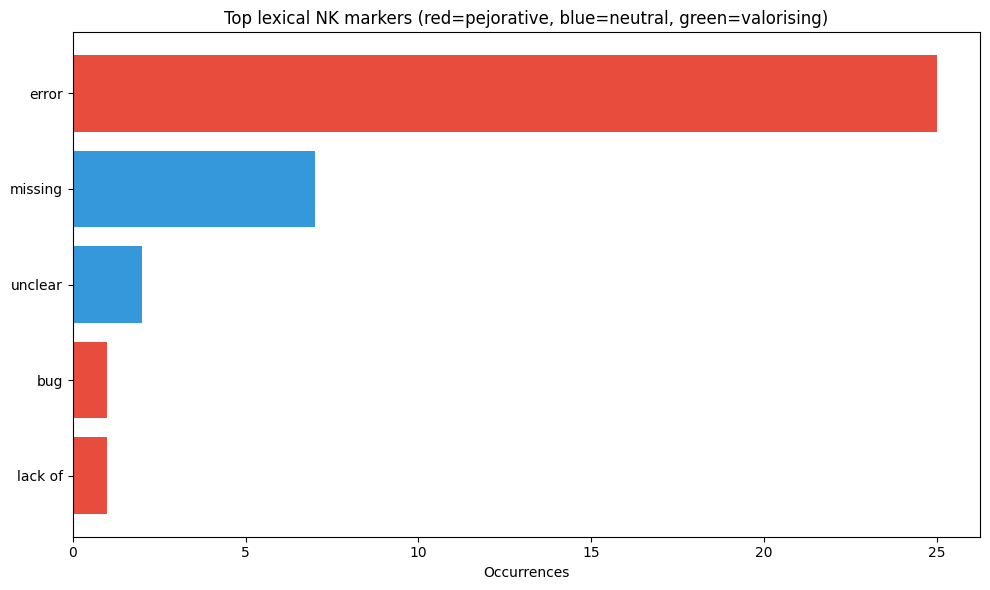

In [8]:
if not df_markers.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = df_markers['polarity'].map({
        'pejorative': '#e74c3c', 'neutral': '#3498db', 'valorising': '#2ecc71'
    }).fillna('#95a5a6')
    ax.barh(df_markers['lemma'], df_markers['occurrences'], color=colors)
    ax.invert_yaxis()
    ax.set_xlabel('Occurrences')
    ax.set_title('Top lexical NK markers (red=pejorative, blue=neutral, green=valorising)')
    plt.tight_layout()
    plt.show()

## 4. Classifier label distribution vs. signal layer-diversity

Scatter: each point is a TextUnit. x = number of distinct linguistic layers
that fired; y = classifier confidence. Colour = classifier label.

Units in the top-left (high confidence, 0 linguistic layers) are classifier
false positives. Units in the bottom-right (many layers, low confidence) are
classifier false negatives. Both are analytically interesting for RQ5.

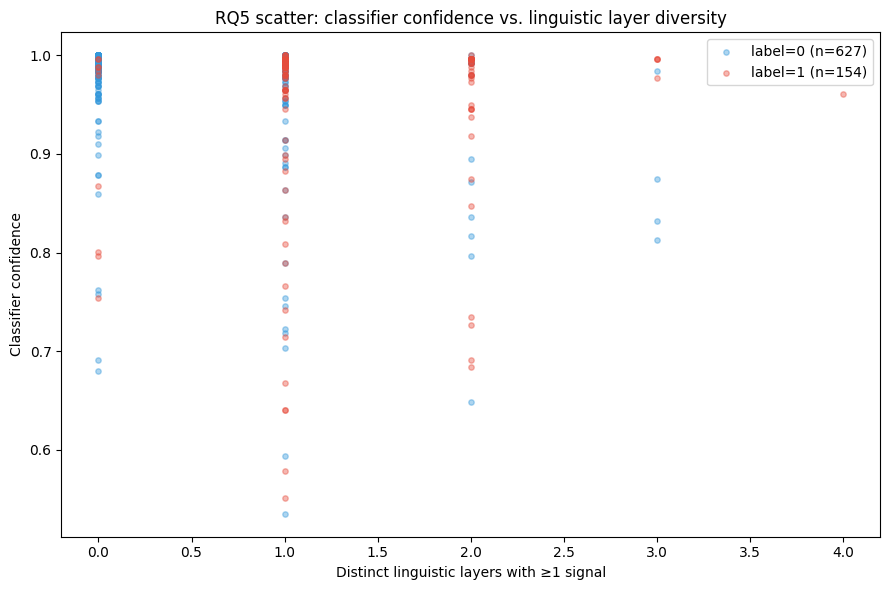

In [9]:
df_rq5_raw = q("""
    MATCH (u:TextUnit)-[:CLASSIFIED_AS]->(v:ClassifierVerdict)
    OPTIONAL MATCH (u)-[:HAS_SIGNAL]->(s:Signal)
    WHERE s.layer IN ['lexical','morpho_syntactic','word_formation','rhetorical']
    WITH u, v, count(DISTINCT s.layer) AS layer_diversity
    RETURN v.label AS label,
           v.confidence AS confidence,
           layer_diversity,
           u.id AS tu_id
""")

if df_rq5_raw.empty:
    print('No ClassifierVerdict nodes yet. Run ClassifierAnnotator first.')
else:
    fig, ax = plt.subplots(figsize=(9, 6))
    for label, grp in df_rq5_raw.groupby('label'):
        color = '#e74c3c' if label == 1 else '#3498db'
        ax.scatter(grp['layer_diversity'], grp['confidence'],
                   alpha=0.4, s=15, c=color,
                   label=f'label={label} (n={len(grp):,})')
    ax.set_xlabel('Distinct linguistic layers with ≥1 signal')
    ax.set_ylabel('Classifier confidence')
    ax.set_title('RQ5 scatter: classifier confidence vs. linguistic layer diversity')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 5. First cut at RQ5: classifier false negatives

TextUnits where the classifier says **0** (no NK) but ≥2 independent
linguistic layers fired. These are the most interesting disagreement cases.
See FRAMEWORK_DESIGN.md §2 RQ5 and BUILD_SPEC.md §6 (RQ5 Cypher).

In [14]:
df_fn = q("""
    MATCH (u:TextUnit)-[:CLASSIFIED_AS]->(v:ClassifierVerdict {label: 0})
    MATCH (u)-[:HAS_SIGNAL]->(s:Signal)
    WHERE s.layer IN ['lexical','morpho_syntactic','word_formation','rhetorical']
    WITH u, v, count(DISTINCT s.layer) AS layer_count
    WHERE layer_count >= 2
    RETURN u.id AS tu_id, u.text AS text,
           v.confidence AS clf_confidence,
           layer_count
    ORDER BY layer_count DESC, clf_confidence DESC
    LIMIT 20
""")

print(f'Potential false negatives (classifier=0, linguistic layers≥2): {len(df_fn)}')
if not df_fn.empty:
    display(df_fn[['text', 'clf_confidence', 'layer_count']])

Potential false negatives (classifier=0, linguistic layers≥2): 18


,text,clf_confidence,layer_count
0,"This is green now, just need to get some clari...",0.984375,3
1,When installing puppet-server on a server whic...,0.875000,3
2,"## Affected Puppet, Ruby, OS and module versio...",0.832031,3
3,"## What are you seeing\r\n\r\nCurrently, it's ...",0.812500,3
4,we are using an internal mirror of the puppetl...,1.000000,2
5,"Thanks for this. Actually, the new version of ...",0.996094,2
6,acceptance tests run from a new system every t...,0.996094,2
7,auth.conf not parsable by the trapperkeeper lens,0.992188,2
8,After installing and configuring my nodes to u...,0.992188,2
9,no reaction for 6 days. re-open or open a new ...,0.992188,2


## 6. Signal layer co-occurrence matrix

Which layers tend to fire together? Relevant for RQ2 prototypical co-occurrences.

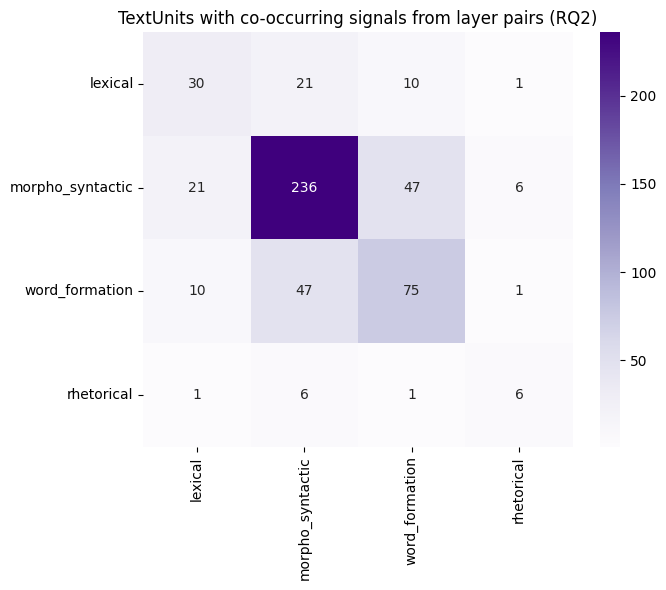

In [15]:
layers = ['lexical', 'morpho_syntactic', 'word_formation', 'rhetorical']

cooc = pd.DataFrame(0, index=layers, columns=layers)
for i, l1 in enumerate(layers):
    for l2 in layers[i:]:
        df_pair = q("""
            MATCH (u:TextUnit)-[:HAS_SIGNAL]->(s1:Signal {layer: $l1})
            MATCH (u)-[:HAS_SIGNAL]->(s2:Signal {layer: $l2})
            RETURN count(DISTINCT u) AS n
        """, l1=l1, l2=l2)
        n = int(df_pair['n'].iloc[0]) if not df_pair.empty else 0
        cooc.loc[l1, l2] = n
        cooc.loc[l2, l1] = n

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cooc, annot=True, fmt='d', cmap='Purples', ax=ax)
ax.set_title('TextUnits with co-occurring signals from layer pairs (RQ2)')
plt.tight_layout()
plt.show()

In [ ]:
driver.close()
print('Done.')